## 🧪 Cài đặt thư viện cần thiết

In [1]:
!pip install ultralytics==8.2.5
!pip install mlflow
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install albumentations opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

## 🔗 Mount Google Drive và giải nén dữ liệu

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/dispatch/dataset.zip -d /content/dataset
!ls /content/dataset/Detection/


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/dataset/Detection/train/labels/img_001196.txt  
  inflating: /content/dataset/Detection/train/labels/img_001000.txt  
  inflating: /content/dataset/Detection/train/labels/img_000759.txt  
  inflating: /content/dataset/Detection/train/labels/img_000646.txt  
  inflating: /content/dataset/Detection/train/labels/img_000262.txt  
  inflating: /content/dataset/Detection/train/labels/img_000431.txt  
  inflating: /content/dataset/Detection/train/labels/img_001068.txt  
  inflating: /content/dataset/Detection/train/labels/img_000825.txt  
  inflating: /content/dataset/Detection/train/labels/img_000490.txt  
  inflating: /content/dataset/Detection/train/labels/img_000414.txt  
  inflating: /content/dataset/Detection/train/labels/img_001141.txt  
  inflating: /content/dataset/Detection/train/labels/img_000446.txt  
  inflating: /content/dataset/Detection/train/labels/img_000394.txt  
  inflating: /content/dataset/Det

In [3]:
import os
# 🔕 Disable W&B logging before importing Ultralytics
!pip uninstall -y wandb
os.environ["WANDB_DISABLED"] = "true"

Found existing installation: wandb 0.21.0
Uninstalling wandb-0.21.0:
  Successfully uninstalled wandb-0.21.0


📁 Train images: /content/dataset/Detection/train/images
📁 Train labels: /content/dataset/Detection/train/labels
🔢 Classes: ['dish', 'tray']


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


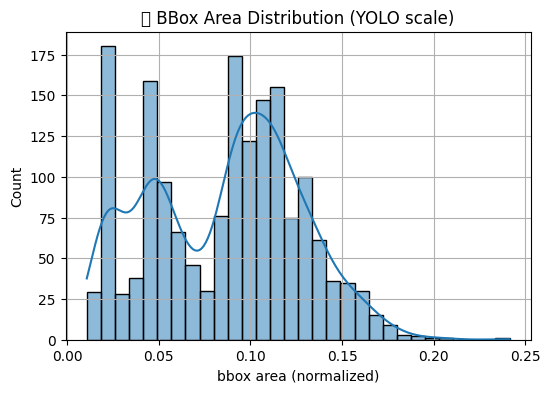

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


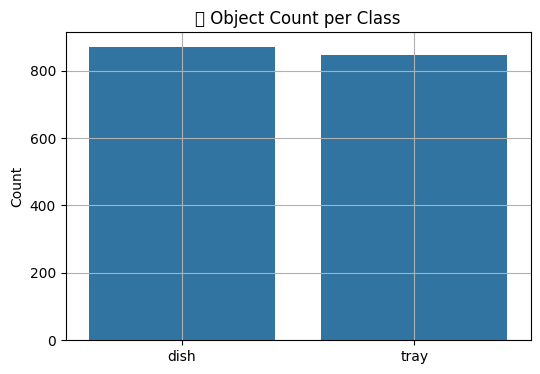

In [4]:
# 📊 Dataset Analysis before Training (Fixed for your structure)
import os
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Load dataset.yaml ==========
dataset_yaml = "/content/dataset/Detection/dataset.yaml"
with open(dataset_yaml, 'r') as f:
    data_cfg = yaml.safe_load(f)

dataset_root = Path(data_cfg['path'])
train_img_dir = dataset_root / data_cfg['train']   # train/images
val_img_dir = dataset_root / data_cfg['val']       # val/images
train_lbl_dir = dataset_root / "train/labels"
val_lbl_dir = dataset_root / "val/labels"
class_names = data_cfg['names']

print(f"📁 Train images: {train_img_dir}")
print(f"📁 Train labels: {train_lbl_dir}")
print(f"🔢 Classes: {class_names}")

# ========== Analyze dataset ==========
def analyze_dataset(img_dir, lbl_dir):
    image_sizes = []
    bbox_areas = []
    class_counts = {i: 0 for i in range(len(class_names))}
    image_exts = [".jpg", ".jpeg", ".png"]

    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in image_exts:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        with Image.open(img_path) as img:
            w, h = img.size
            image_sizes.append((w, h))

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                class_counts[int(cls)] += 1
                bbox_areas.append(bw * bh)  # normalized area

    return image_sizes, bbox_areas, class_counts

# Run analysis on training set
img_sizes, bbox_areas, class_dist = analyze_dataset(train_img_dir, train_lbl_dir)

# ========== Visualize ==========
# BBox area distribution
plt.figure(figsize=(6,4))
sns.histplot(bbox_areas, bins=30, kde=True)
plt.title("📏 BBox Area Distribution (YOLO scale)")
plt.xlabel("bbox area (normalized)")
plt.grid()
plt.show()

# Class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=[class_names[k] for k in class_dist.keys()], y=list(class_dist.values()))
plt.title("📊 Object Count per Class")
plt.ylabel("Count")
plt.grid()
plt.show()



📦 1. Biểu đồ diện tích bounding box (BBox Area Distribution)
Nhận xét:

Khoảng 30–40% các object có diện tích nhỏ hơn 0.05 (trên thang YOLO normalized).

Phân bố không đều, có nhiều đỉnh → có thể do object size thay đổi mạnh giữa các ảnh.

Đề xuất cải thiện:

✅ Tăng imgsz khi training YOLO (ví dụ: từ 640 ➜ 960 hoặc 1088) để giúp YOLO học được các object nhỏ.

✅ Tăng augmentation với các object nhỏ:

mosaic=1.0, copy_paste=0.2, hsv_h=0.015...

❗ Tránh giảm chất lượng ảnh quá mức khi resize.


📦 2. Biểu đồ phân bố object theo class (Object Count per Class)
Nhận xét:

Cân bằng tuyệt vời 🟢: Số lượng dish và tray gần bằng nhau (~850 mỗi class).

Không có class nào bị thiếu hoặc overrepresented.

Hành động:

✅ Không cần oversampling hay re-weighting loss function.

✅ Có thể dùng default class weights khi huấn luyện.

## 🎨 Augmentation sinh vật thể nhỏ mô phỏng thực tế

In [27]:

import albumentations as A
import cv2
from pathlib import Path

tray_transform = A.Compose([
    A.OneOf([
        A.RandomResizedCrop(size=(1088, 1088), scale=(0.1, 0.15), ratio=(0.8, 1.2), p=0.6),
        A.PadIfNeeded(min_height=1088, min_width=1088, value=114, p=0.4)
    ], p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(0.05, 0.15), contrast_limit=(0.2, 0.4), p=1.0),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.3),
    A.Equalize(p=0.1),
    A.ISONoise(color_shift=(0.01, 0.1), intensity=(0.1, 0.5), p=0.2),
    A.Perspective(scale=(0.05, 0.08), p=0.6),
    A.RandomShadow(p=0.3),
    # A.Resize(1088, 1088),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

def augment_dish_only(image_dir, label_dir, output_img_dir, output_lbl_dir, n_aug=2):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)
    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    total_aug = 0

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        image = cv2.imread(str(img_path))
        bboxes = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                if int(cls) == 1:
                    bboxes.append([x, y, bw, bh])

        if not bboxes:
            continue

        class_labels = [1] * len(bboxes)

        for i in range(n_aug):
            try:
                augmented = tray_transform(
                    image=image,
                    bboxes=bboxes,
                    class_labels=class_labels
                )
            except Exception as e:
                print(f"❌ Aug failed on {img_path.name}: {e}")
                continue

            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]

            if not aug_bboxes:
                continue

            aug_name = f"{img_path.stem}_aug{i}"
            cv2.imwrite(str(output_img_dir / f"{aug_name}.jpg"), aug_img)
            with open(output_lbl_dir / f"{aug_name}.txt", "w") as f:
                for bbox in aug_bboxes:
                    f.write(f"0 {' '.join(map(str, bbox))}\n")

            total_aug += 1

    print(f"✅ Augmented {total_aug} tray images")


/tmp/ipython-input-27-2964327581.py:8: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=1088, min_width=1088, value=114, p=0.4)


In [26]:
# shutil.rmtree('/content/tray_yolo_dataset', ignore_errors=True)


:## 🧪 Sinh ảnh augment kèm nhãn (YOLO) và resize chuẩn

In [28]:
augment_dish_only(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    output_img_dir="/content/tray_yolo_dataset/train/images",
    output_lbl_dir="/content/tray_yolo_dataset/train/labels",
    n_aug=3
)


✅ Augmented 1284 tray images


In [29]:
from pathlib import Path
import shutil

def filter_val_dish_only(input_img_dir, input_lbl_dir, output_img_dir, output_lbl_dir):
    input_img_dir = Path(input_img_dir)
    input_lbl_dir = Path(input_lbl_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)

    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(input_img_dir.glob("*.jpg")) + list(input_img_dir.glob("*.png"))
    kept = 0

    for img_path in image_paths:
        lbl_path = input_lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        dish_lines = [l for l in lines if l.strip().startswith("1")]

        if not dish_lines:
            continue

        # Copy ảnh + ghi lại label chỉ có class 0
        shutil.copy(img_path, output_img_dir / img_path.name)
        with open(output_lbl_dir / f"{img_path.stem}.txt", "w") as f:
            for l in dish_lines:
                parts = l.strip().split()
                if len(parts) == 5:
                    x, y, w, h = parts[1:]
                    f.write(f"0 {x} {y} {w} {h}\n")
        kept += 1

    print(f"✅ Đã lọc {kept} ảnh chứa tray từ tập val.")

# Gọi hàm xử lý:
filter_val_dish_only(
    input_img_dir="/content/dataset/Detection/val/images",
    input_lbl_dir="/content/dataset/Detection/val/labels",
    output_img_dir="/content/tray_yolo_dataset/val/images",
    output_lbl_dir="/content/tray_yolo_dataset/val/labels"
)


✅ Đã lọc 180 ảnh chứa tray từ tập val.


In [30]:
# Ghi file data.yaml cho tray
data_yaml = '''path: /content/tray_yolo_dataset
train: train/images
val: val/images
names:
  0: tray
'''

with open("/content/tray_yolo_dataset/data_tray.yaml", "w") as f:
    f.write(data_yaml)

print("✅ Created data_tray.yaml")


✅ Created data_tray.yaml


In [31]:
from pathlib import Path

def check_aug_image_label_match(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_stems = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    label_stems = set(p.stem for p in label_dir.glob("*.txt"))

    matched = image_stems & label_stems
    img_only = image_stems - label_stems
    lbl_only = label_stems - image_stems

    print(f"🧪 Tổng ảnh augment: {len(image_stems)}")
    print(f"🏷️ Tổng nhãn augment: {len(label_stems)}")
    print(f"✅ Khớp đúng: {len(matched)}")
    print(f"⚠️ Ảnh KHÔNG có nhãn: {len(img_only)}")
    if img_only:
        print("  🔸 Ví dụ ảnh thiếu nhãn:")
        for name in list(img_only)[:5]:
            print(f"    ⚠️ {name}.jpg")
    print(f"⚠️ Nhãn KHÔNG có ảnh: {len(lbl_only)}")
    if lbl_only:
        print("  🔸 Ví dụ nhãn thiếu ảnh:")
        for name in list(lbl_only)[:5]:
            print(f"    ⚠️ {name}.txt")

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/tray_yolo_dataset/train/images",
    label_dir="/content/tray_yolo_dataset/train/labels"
)

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/tray_yolo_dataset/val/images",
    label_dir="/content/tray_yolo_dataset/val/labels"
)


🧪 Tổng ảnh augment: 1284
🏷️ Tổng nhãn augment: 1284
✅ Khớp đúng: 1284
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0
🧪 Tổng ảnh augment: 180
🏷️ Tổng nhãn augment: 180
✅ Khớp đúng: 180
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0


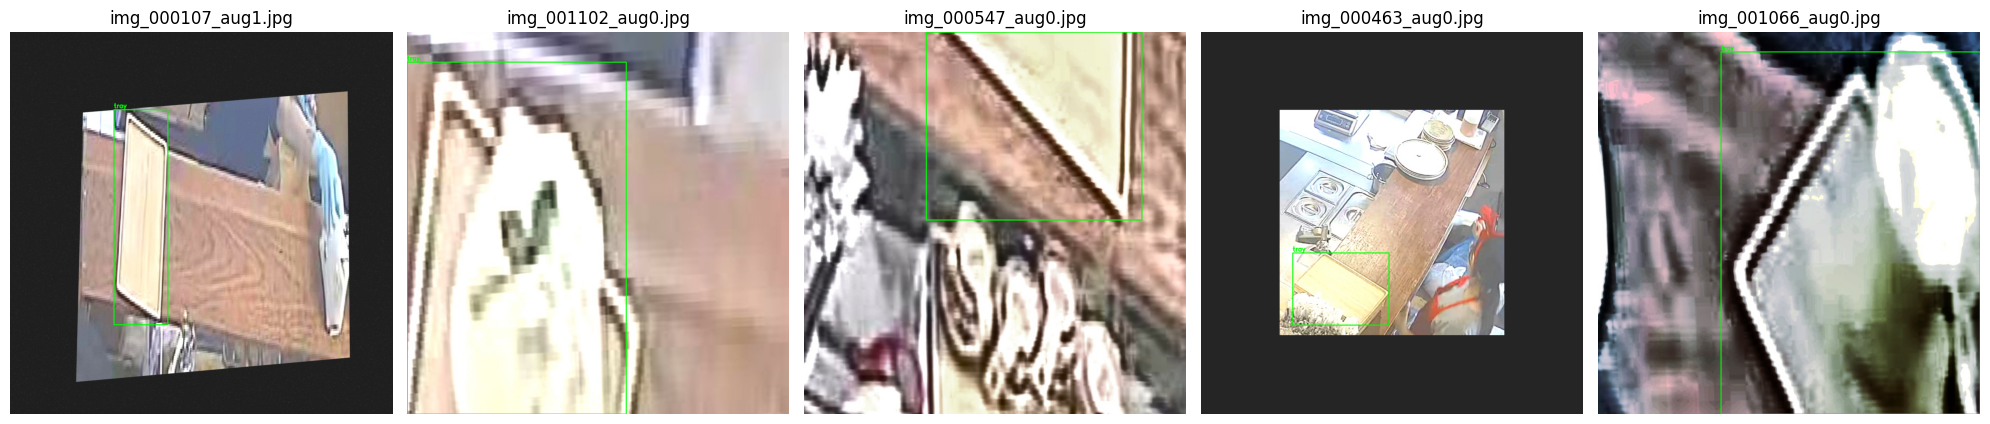

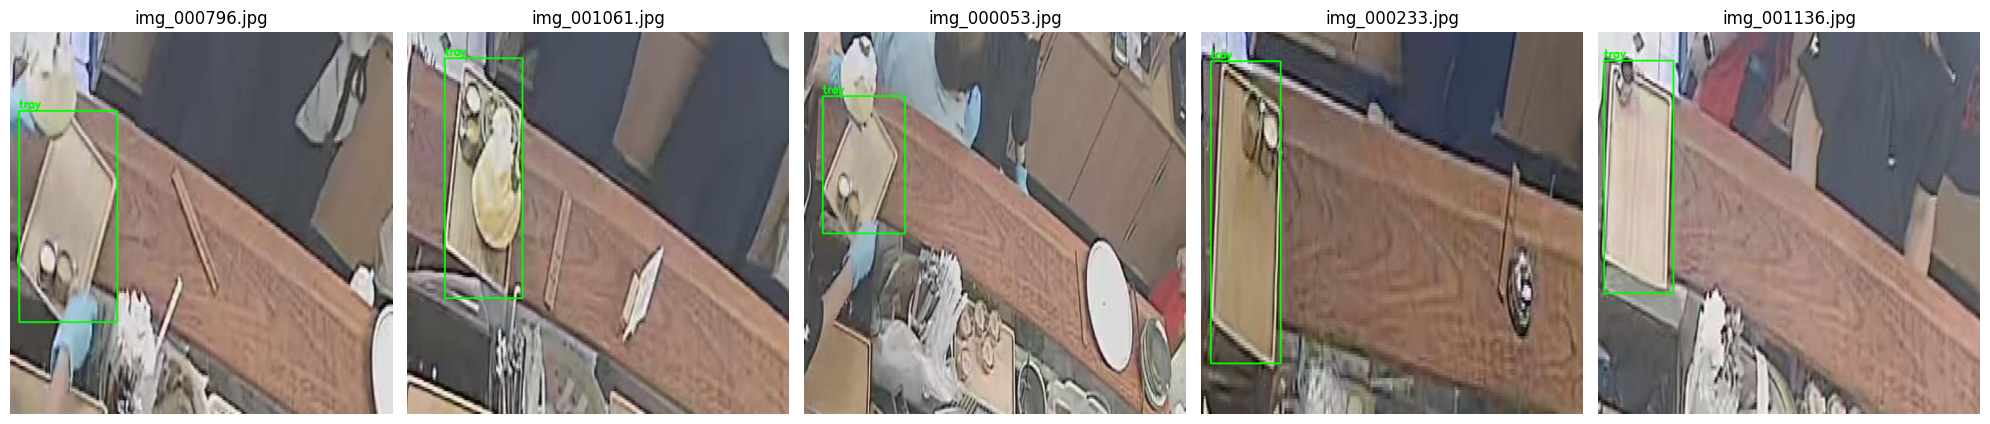

In [40]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

def draw_bbox_yolo(image_path, label_path, class_names=None):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not label_path.exists():
        return img  # no bbox

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_center, y_center, bw, bh = map(float, parts)
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            x2 = int((x_center + bw / 2) * w)
            y2 = int((y_center + bh / 2) * h)
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[int(cls_id)] if class_names else str(int(cls_id))
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

def visualize_random_bboxes(image_dir, label_dir, n=5, class_names=None):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    image_paths = [p for p in image_paths if (label_dir / f"{p.stem}.txt").exists()]
    if not image_paths:
        print("⚠️ Không tìm thấy ảnh nào có nhãn hợp lệ.")
        return

    selected = random.sample(image_paths, min(n, len(image_paths)))

    fig, axes = plt.subplots(1, len(selected), figsize=(20, 6))
    if len(selected) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, selected):
        label_path = label_dir / f"{img_path.stem}.txt"
        img = draw_bbox_yolo(img_path, label_path, class_names)
        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 🔍 Gọi cho tập train
visualize_random_bboxes(
    image_dir="/content/tray_yolo_dataset/train/images",
    label_dir="/content/tray_yolo_dataset/train/labels",
    n=5,
    class_names=["tray"]
)

#🔍 Gọi cho tập val
visualize_random_bboxes(
    image_dir="/content/tray_yolo_dataset/val/images",
    label_dir="/content/tray_yolo_dataset/val/labels",
    n=5,
    class_names=["tray"]
)

## 🚀 Huấn luyện YOLOv8 tối ưu cho object nhỏ

In [41]:
from ultralytics import YOLO
import mlflow
import torch

mlflow.set_tracking_uri("https://3362277a1788.ngrok-free.app")
mlflow.set_experiment("dispatch-yolov8-dish-v1")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_params = {
    "model": "yolov8n",
    "epochs": 100,
    "imgsz": 1088,
    "batch": 16,
    "patience": 20,

    # Chỉ giữ các augment nhẹ, bổ trợ
    # "hsv_h": 0.005,         # rất nhẹ, vì đã HSV trong albumentations
    # "copy_paste": 0.1,      # giữ nhẹ nếu thiếu tray/dish nhỏ
    # "mosaic": 0.5,          # chỉ dùng nhẹ nếu ảnh ít object
    # "scale": 0.2,           # tránh làm méo object quá nhiều
    # "translate": 0.05,      # không dịch nhiều (ảnh bạn gần như cố định)
    "perspective": 0.0,     # disable vì đã augment tay rồi
    "fliplr": 0.3,          # giữ ở mức vừa phải
    "flipud": 0.0,          # KHÔNG dùng trong context camera cố định
    "degrees": 0.0,         # không xoay trong YOLO vì đã xoay rồi trước đó
    "workers": 2,           # Số workers nhỏ tránh overload RAM/CPU Colab
    "cache": False,          # Tăng tốc nếu dữ liệu nhỏ vừa RAM (không dùng nếu RAM < 15GB)
    "note": "Tối ưu augment thủ công cho 1 class tray"
}


with mlflow.start_run(run_name="yolov8n_aug_tray_only"):
    mlflow.log_params(train_params)

    ### new training  ###
    model = YOLO("yolov8n.pt")

    ### retraining   ###
    # model = YOLO("/content/runs/detect/yolov8n_aug_tray_only/weights/best.pt")

    results = model.train(
        data="/content/tray_yolo_dataset/data_tray.yaml",
        device=device,
        # name="yolov8s_dispatch_smallobj",
        name="yolov8n_aug_tray_only_1",  # 👈 tránh ghi đè vào thư mục cũ
        # resume=True, ## Cần thiết cho retrain
        **{k: v for k, v in train_params.items() if k not in ["model", "note"]}
    )

    if hasattr(results, "metrics"):
        mlflow.log_metrics({
            "map50": results.metrics.box.map50,
            "map": results.metrics.box.map,
            "precision": results.metrics.box.precision,
            "recall": results.metrics.box.recall
        })


New https://pypi.org/project/ultralytics/8.3.167 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/tray_yolo_dataset/data_tray.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=yolov8n_aug_tray_only_12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_c

train: Scanning /content/tray_yolo_dataset/train/labels... 1284 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1284/1284 [00:00<00:00, 2502.45it/s]

train: WARNING ⚠️ /content/tray_yolo_dataset/train/images/img_001108_aug0.jpg: 1 duplicate labels removed
train: New cache created: /content/tray_yolo_dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.11/dist-packages/ultralytics/data/augment.py:891: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/tray_yolo_dataset/val/labels... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<00:00, 1002.79it/s]

val: New cache created: /content/tray_yolo_dataset/val/labels.cache


...

                   all        180        199      0.985      0.984      0.988      0.858



100 epochs completed in 1.757 hours.
Optimizer stripped from runs/detect/yolov8n_aug_tray_only_12/weights/last.pt, 6.4MB
Optimizer stripped from runs/detect/yolov8n_aug_tray_only_12/weights/best.pt, 6.4MB

Validating runs/detect/yolov8n_aug_tray_only_12/weights/best.pt...
Ultralytics YOLOv8.2.5 🚀 Python-3.11.13 torch-2.5.1+cu118 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:08<00:00,  1.47s/it]


                   all        180        199      0.995      0.979      0.993      0.861
Speed: 0.8ms preprocess, 8.4ms inference, 0.1ms loss, 7.4ms postprocess per image
Results saved to runs/detect/yolov8n_aug_tray_only_12
🏃 View run yolov8n_aug_tray_only at: https://3362277a1788.ngrok-free.app/#/experiments/124846726613890110/runs/57ae7ab6d4584da2a9a84dcfd265a9e4
🧪 View experiment at: https://3362277a1788.ngrok-free.app/#/experiments/124846726613890110


MlflowException: API request to https://3362277a1788.ngrok-free.app/api/2.0/mlflow-artifacts/artifacts/124846726613890110/57ae7ab6d4584da2a9a84dcfd265a9e4/artifacts/weights/last.pt failed with exception HTTPSConnectionPool(host='3362277a1788.ngrok-free.app', port=443): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/124846726613890110/57ae7ab6d4584da2a9a84dcfd265a9e4/artifacts/weights/last.pt (Caused by ResponseError('too many 500 error responses'))

| Chỉ số            | Giá trị                                           |
| ----------------- | ------------------------------------------------- |
| **Precision (P)** | **0.995** → gần như không có false positive       |
| **Recall (R)**    | **0.979** → phát hiện gần như đầy đủ các tray     |
| **mAP\@0.5**      | **0.993** → rất sát với hoàn hảo                  |
| **mAP\@0.5:0.95** | **0.861** → rất tốt, đặc biệt với YOLOv8n nhỏ gọn |


In [42]:
!zip -r runs_yolo_tray_v1.zip runs/
from google.colab import files
files.download("runs_yolo_tray_v1.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/yolov8n_aug_tray_only_12/ (stored 0%)
  adding: runs/detect/yolov8n_aug_tray_only_12/P_curve.png (deflated 24%)
  adding: runs/detect/yolov8n_aug_tray_only_12/train_batch0.jpg (deflated 6%)
  adding: runs/detect/yolov8n_aug_tray_only_12/PR_curve.png (deflated 29%)
  adding: runs/detect/yolov8n_aug_tray_only_12/events.out.tfevents.1752731817.a27f12036ba3.707.1 (deflated 87%)
  adding: runs/detect/yolov8n_aug_tray_only_12/results.csv (deflated 85%)
  adding: runs/detect/yolov8n_aug_tray_only_12/R_curve.png (deflated 19%)
  adding: runs/detect/yolov8n_aug_tray_only_12/labels.jpg (deflated 20%)
  adding: runs/detect/yolov8n_aug_tray_only_12/confusion_matrix_normalized.png (deflated 38%)
  adding: runs/detect/yolov8n_aug_tray_only_12/val_batch0_labels.jpg (deflated 2%)
  adding: runs/detect/yolov8n_aug_tray_only_12/train_batch1.jpg (deflated 8%)
  adding: runs/detect/yolov8n_aug_tray_only_12/val_batch2_pred

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lưu tạm /content/runs/ vào /content/drive/MyDrive/dispatch/runs để ngày mai train tiếp

In [ ]:
import shutil

# Tạo thư mục đích nếu chưa có
!mkdir -p /content/drive/MyDrive/dispatch

# Sao chép toàn bộ thư mục runs/ vào Drive
shutil.copytree('/content/runs', '/content/drive/MyDrive/dispatch/runs', dirs_exist_ok=True)
print("✅ Sao chép runs/ vào Drive thành công.")


Copy thư mục runs/ từ Drive ngược lại Colab để train tiếp

In [ ]:
import shutil

# Xóa thư mục runs/ cũ nếu có (để tránh trùng lặp hoặc lỗi)
!rm -rf /content/runs

# Copy từ Drive ngược lại vào Colab
shutil.copytree('/content/drive/MyDrive/dispatch/runs', '/content/runs', dirs_exist_ok=True)
print("✅ Khôi phục runs/ từ Drive vào Colab thành công.")
